# Kuiper statistic analysis

In this notebook, I compare the Kuiper statistics between daily maximum values / anomalies and bootstrapped Kuiper statistics from both stationary and fitted parameter values. The goal is to show that all of these are too similar to rule out, which lets us use a GEV distribution to characterize trends in extreme temperatures.

In [1]:
# import base packages for data analysis
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import xesmf as xe
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from scipy.stats import genextreme, describe
from astropy.stats import kuiper, kuiper_two

from src.utils import compute_ecdf

# import custom stuff
from ambpy.plotutils import make_figure_filename
plt.style.use('ambpy')

# set random attributes
np.random.seed(4)

save_figs = True

In [2]:
ds_max = xr.open_dataset('data/ERA5/landonly/era5_t2m_annual_max_1deg_landonly_gev_stat_kuiper.nc', engine='netcdf4')
ds_min = xr.open_dataset('data/ERA5/landonly/era5_t2m_annual_max_1deg_landonly_gevfitted_kuiper.nc', engine='netcdf4')
ds_boot = xr.open_dataset('data/stats/bootstrapped_ks.nc', engine='netcdf4')

In [3]:
ds_max

<xarray.Dataset> Size: 44MB
Dimensions:     (year: 75, lat: 180, lon: 360)
Coordinates:
  * lat         (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
  * lon         (lon) int64 3kB 0 1 2 3 4 5 6 7 ... 353 354 355 356 357 358 359
  * year        (year) int64 600B 1950 1951 1952 1953 ... 2021 2022 2023 2024
Data variables:
    t2m         (year, lat, lon) float32 19MB ...
    t2m_anom    (year, lat, lon) float32 19MB ...
    loc_raw     (lat, lon) float64 518kB ...
    scale_raw   (lat, lon) float64 518kB ...
    shape_raw   (lat, lon) float64 518kB ...
    loc_anom    (lat, lon) float64 518kB ...
    scale_anom  (lat, lon) float64 518kB ...
    shape_anom  (lat, lon) float64 518kB ...
    obs_k_raw   (lat, lon) float64 518kB ...
    syn_k_raw   (lat, lon) float64 518kB ...
    obs_k_anom  (lat, lon) float64 518kB ...
    syn_k_anom  (lat, lon) float64 518kB ...

In [4]:
ds_boot

<xarray.Dataset> Size: 16kB
Dimensions:  (iter: 1000)
Coordinates:
  * iter     (iter) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
Data variables:
    boot_ks  (iter) float64 8kB ...
Attributes:
    shape:    -0.25
    loc:      20.0
    scale:    1.5

## Kuiper statistic CDFs

In [5]:
def plot_kuiper_max_min_ecdf(ds_max, ds_min, ds_boot, k_type, xlim=False,
                             filename_args=['kuiper', 'png', 'figs']):
    obs_k_max = ds_max['obs_k_' + k_type].values.flatten()
    syn_k_max = ds_max['syn_k_' + k_type].values.flatten()

    obs_k_min = ds_min['obs_k_' + k_type].values.flatten()
    syn_k_min = ds_min['syn_k_' + k_type].values.flatten()
    
    # ignore -1 values (ocean)
    k_max = 0.35
    obs_k_max = obs_k_max[(obs_k_max >= 0.0) & (obs_k_max < k_max)]
    syn_k_max = syn_k_max[(syn_k_max >= 0.0) & (syn_k_max < k_max)]

    # ignore -1 values (ocean)
    obs_k_min = obs_k_min[(obs_k_min >= 0.0) & (obs_k_min < k_max)]
    syn_k_min = syn_k_min[(syn_k_min >= 0.0) & (syn_k_min < k_max)]

    # bootstrapped ks
    boot_k = ds_boot['boot_ks'].values.flatten()

    obs_k_max_cdf, obs_k_max_probs = compute_ecdf(obs_k_max, extend_lower=True, extend_upper=False)
    syn_k_max_cdf, syn_k_max_probs = compute_ecdf(syn_k_max, extend_lower=True, extend_upper=False)
    
    obs_k_min_cdf, obs_k_min_probs = compute_ecdf(obs_k_min, extend_lower=True, extend_upper=False)
    syn_k_min_cdf, syn_k_min_probs = compute_ecdf(syn_k_min, extend_lower=True, extend_upper=False)
    
    boot_k_cdf, boot_k_probs = compute_ecdf(boot_k, extend_lower=True, extend_upper=True,
                                            ub=max(max(syn_k_min_cdf), max(obs_k_min_cdf),
                                                   max(syn_k_max_cdf), max(obs_k_max_cdf)))

    # create figure
    fig, ax = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True, sharey=True)

    # first panel: maximum temperatures
    ax[0].plot(obs_k_max_cdf, obs_k_max_probs, label='ERA5, Land only',
              linewidth=3)
    ax[0].plot(syn_k_max_cdf, syn_k_max_probs, label='Bootstrapped,\nfitted parameters',
              linewidth=2, linestyle='dashed')
    ax[0].plot(boot_k_cdf, boot_k_probs, label='Bootstrapped,\nstationary parameters',
              linewidth=2, linestyle='dotted')

    # second panel: minimum temperatures
    ax[1].plot(obs_k_min_cdf, obs_k_min_probs, label='ERA5, Land only',
              linewidth=3)
    ax[1].plot(syn_k_min_cdf, syn_k_min_probs, label='Bootstrapped,\nfitted parameters',
              linewidth=2, linestyle='dashed')
    ax[1].plot(boot_k_cdf, boot_k_probs, label='Bootstrapped,\nstationary parameters',
              linewidth=2, linestyle='dotted')
    
    for a in ax:
        a.set_xlabel('Kuiper statistic')
    
    ax[1].legend()
    
    ax[0].set_ylabel('CDF')

    if k_type == 'raw':
        ax[0].set_title("Annual maximum temperature anomalies (raw)")
        ax[1].set_title("Annual minimum temperature anomalies (raw)")
        
    elif k_type == 'anom':
        ax[0].set_title("Annual maximum temperature anomalies\nrelative to annual mean")
        ax[1].set_title("Annual minimum temperature anomalies\nrelative to annual mean")

    else:
        raise ValueError("Invalid k_type parameter passed.")

    if xlim:
        for ax in ax.flat:
            ax.set_xlim((0, 0.35))

    if save_figs:
        fig.savefig(make_figure_filename(*filename_args), dpi=300)
        print('Figure saved!')

Figure saved!


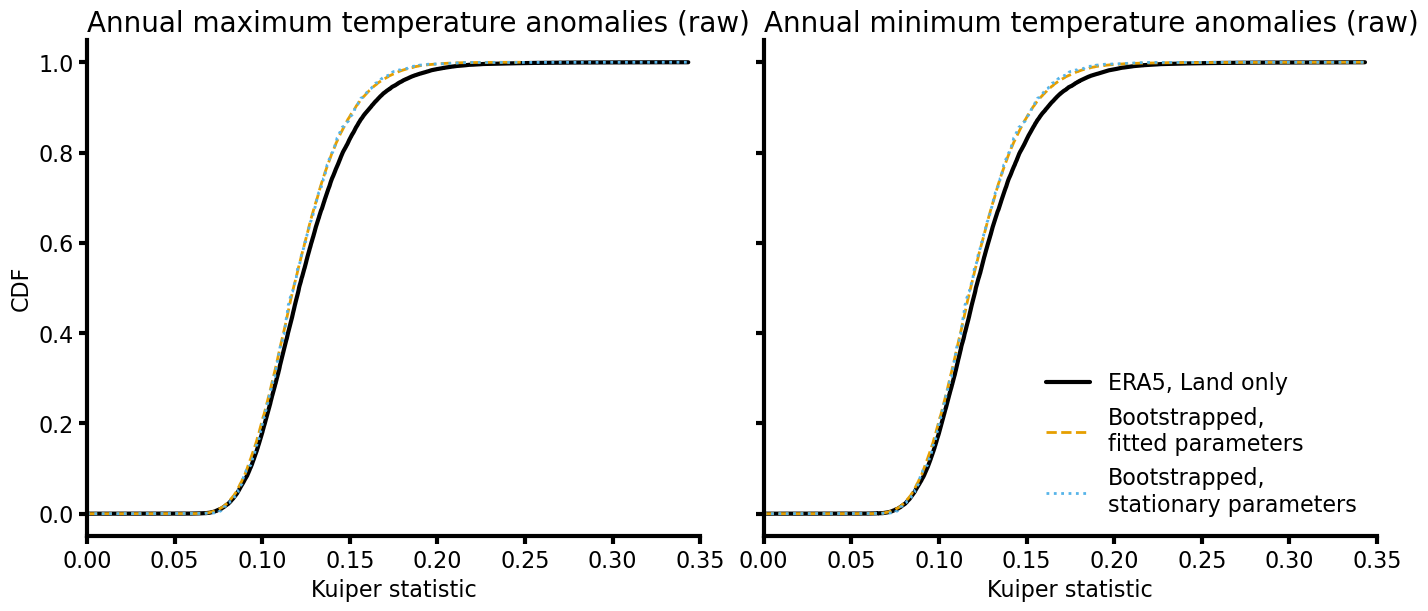

In [6]:
plot_kuiper_max_min_ecdf(ds_max, ds_min, ds_boot, 'raw', xlim=True, filename_args=['kuiper-daily-max-raw-ecdf', 'png', 'figs'])

Figure saved!


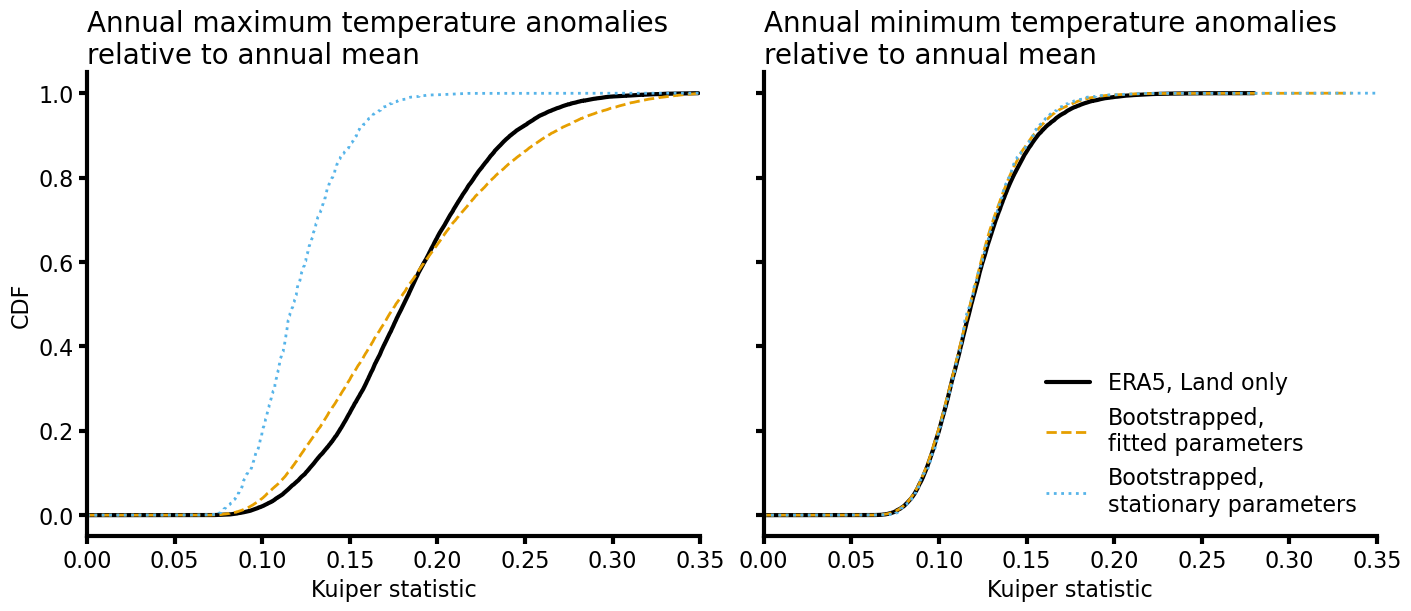

In [6]:
plot_kuiper_max_min_ecdf(ds_max, ds_min, ds_boot, 'anom', xlim=True, filename_args=['kuiper-daily-max-anom-ecdf', 'png', 'figs'])

## GEV parameter maps

In [37]:
def plot_gev_parameters(shape, loc, scale, k, titles=None, save_fig=True,
                        filename_args=['gev-k', 'png', 'figs']):
    """
    Plot four xarray DataArrays (shape, loc, scale, k) on a 2x2 world map grid.

    Parameters
    ----------
    shape, loc, scale, k : xr.DataArray
        2D DataArrays with coordinates (lat, lon)
    titles : list or tuple of str, optional
        Custom titles for the subplots. Defaults to ['Shape', 'Location', 'Scale', 'k'].
    save_fig : bool, optional
        If True, saves the figure to `fname`.
    fname : str, optional
        Output filename if save_fig=True.
    """

    if titles is None:
        titles = ["GEV Shape", "GEV Location", "GEV Scale", "Kuiper Statistic (obs)"]

    # Set up the 2x2 grid
    fig, axes = plt.subplots(
        nrows=2, ncols=2,
        figsize=(14, 8),
        subplot_kw={'projection': ccrs.PlateCarree()}
    )

    params = [shape, loc, scale, k]

    for ax, da, title in zip(axes.flat, params, titles):
        # Add map features
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
        ax.add_feature(cfeature.BORDERS, linewidth=0.3)
        ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.5)
        ax.add_feature(cfeature.OCEAN, facecolor="white")

        # Plot the parameter
        im = da.plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            cmap="viridis",
            add_colorbar=False
        )

        # Add an aligned colorbar on the right of each plot
        cbar = fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.046, pad=0.04)
        cbar.set_label(title)

        ax.set_title(title)

    plt.tight_layout()
    if save_fig:
        plt.savefig(make_figure_filename(*filename_args), dpi=300, bbox_inches="tight")
        print('Figure saved!')
    plt.show()

Figure saved!


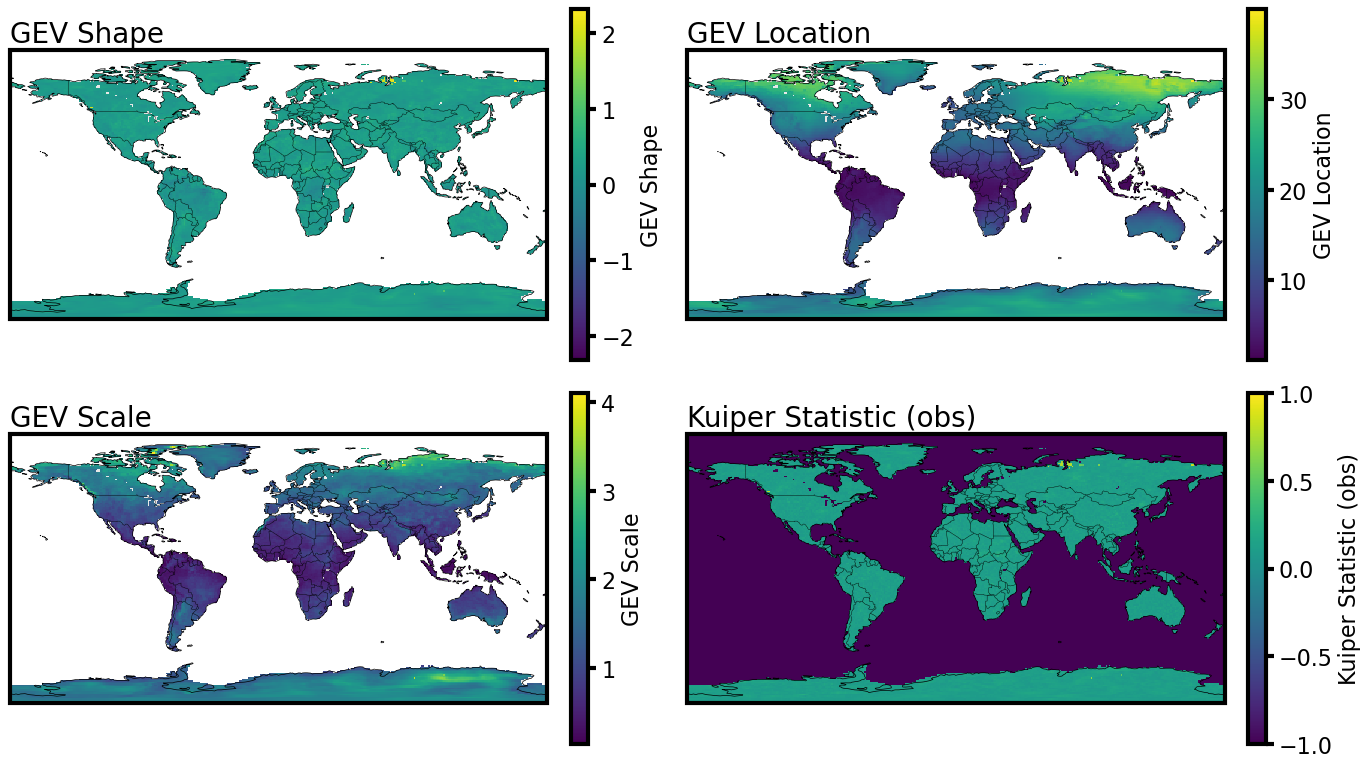

In [38]:
plot_gev_parameters(ds_max['shape_anom'],
                    ds_max['loc_anom'],
                    ds_max['scale_anom'],
                    ds_max['obs_k_anom'],
                    filename_args=['gev-kuiper-maps-annual-max-anom', 'png', 'figs'])

Figure saved!


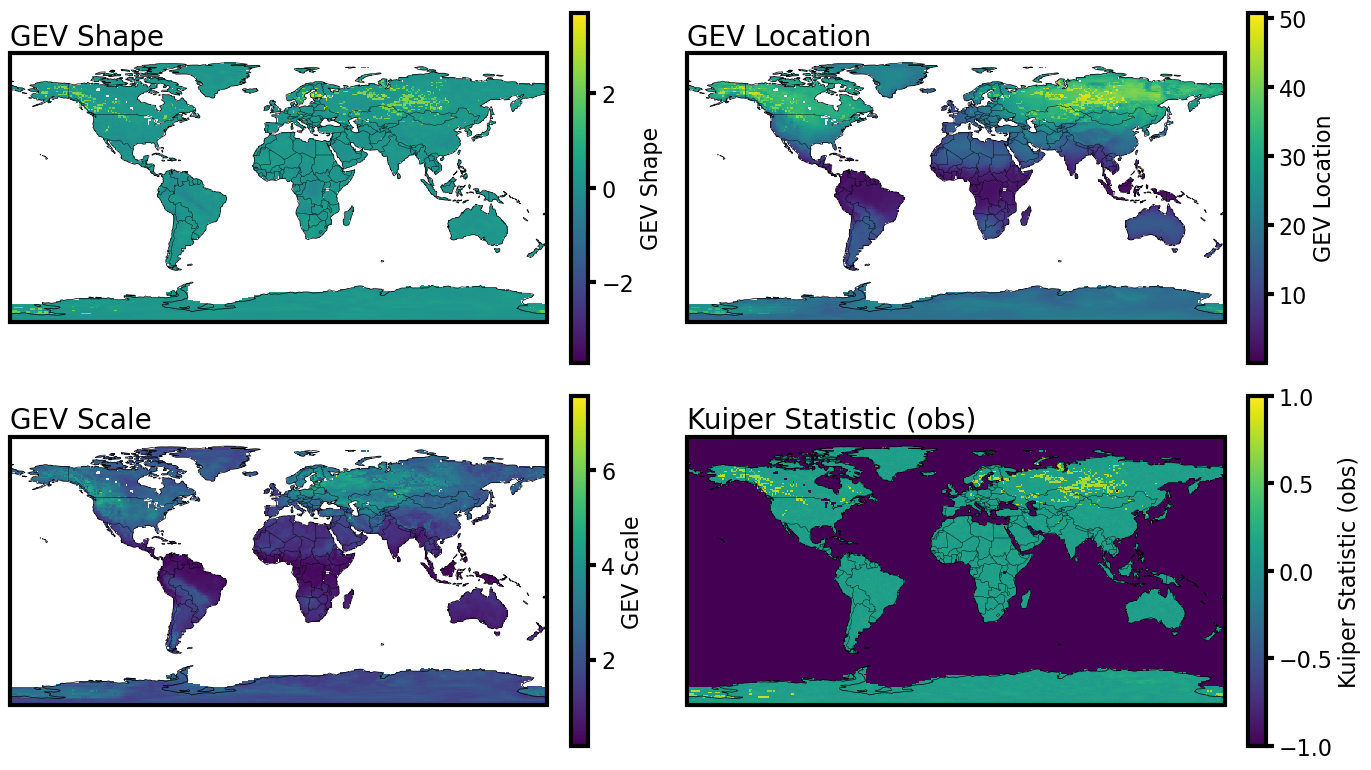

In [39]:
plot_gev_parameters(ds_min['shape_anom'],
                    ds_min['loc_anom'],
                    ds_min['scale_anom'],
                    ds_min['obs_k_anom'],
                    filename_args=['gev-kuiper-maps-annual-min', 'png', 'figs'])

# OLD

In [ ]:
def plot_kuiper_max_min(ds_max, ds_min, ds_boot, k_type, xlim=False,
                        filename_args=['kuiper', 'png', 'figs']):
    obs_k_max = ds_max['obs_k_' + k_type].values.flatten()
    syn_k_max = ds_max['syn_k_' + k_type].values.flatten()

    obs_k_min = ds_min['obs_k_' + k_type].values.flatten()
    syn_k_min = ds_min['syn_k_' + k_type].values.flatten()
    
    # ignore -1 values (ocean)
    obs_k_max = obs_k_max[(obs_k_max >= 0.0) & (obs_k_max < 1.0)]
    syn_k_max = syn_k_max[syn_k_max >= 0.0]

    # ignore -1 values (ocean)
    obs_k_min = obs_k_min[(obs_k_min >= 0.0) & (obs_k_min < 1.0)]
    syn_k_min = syn_k_min[syn_k_min >= 0.0]

    # bootstrapped ks
    boot_k = ds_boot['boot_ks'].values.flatten()

    # create figure
    fig, ax = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True, sharey=True)

    # first panel: maximum temperatures
    ax[0].hist(obs_k_max, cumulative=True, density=True, bins=10000,
           histtype='step', label='Observations')
    ax[0].hist(syn_k_max, cumulative=True, density=True, bins=10000,
           histtype='step', label='Bootstrapped, fitted parameters')
    ax[0].hist(boot_k, cumulative=True, density=True, bins=10000,
           histtype='step', label='Bootstrapped, stationary parameters')

    # second panel: minimum temperatures
    ax[1].hist(obs_k_min, cumulative=True, density=True, bins=10000,
           histtype='step', label='Observations')
    ax[1].hist(syn_k_min, cumulative=True, density=True, bins=10000,
           histtype='step', label='Bootstrapped, fitted parameters')
    ax[1].hist(boot_k, cumulative=True, density=True, bins=10000,
           histtype='step', label='Bootstrapped, stationary parameters')
    
    for a in ax:
        a.set_xlabel('Kuiper statistic')
    
    ax[1].legend()
    
    ax[0].set_ylabel('CDF')

    if k_type == 'raw':
        ax[0].set_title("Annual maximum temperature anomalies (raw)")
        ax[1].set_title("Annual minimum temperature anomalies (raw)")
        
    elif k_type == 'anom':
        ax[0].set_title("Annual maximum temperature anomalies\nrelative to annual mean")
        ax[1].set_title("Annual minimum temperature anomalies\nrelative to annual mean")

    else:
        raise ValueError("Invalid k_type parameter passed.")

    if xlim:
        for ax in ax.flat:
            ax.set_xlim((0, 0.35))

    if save_figs:
        fig.savefig(make_figure_filename(*filename_args), dpi=300)
        print('Figure saved!')

In [ ]:
plot_kuiper_max_min(ds_max, ds_max, ds_boot, 'anom', xlim=True, filename_args=['kuiper-daily-max-raw', 'png', 'figs'])

In [ ]:
plot_kuiper_max_min(ds_max, ds_max, ds_boot, 'raw', xlim=True, filename_args=['kuiper-daily-max-raw', 'png', 'figs'])